In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP_new import DP
import matplotlib.pyplot as plt
import numpy as np

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [3]:
# new-schema output catalogs (parent + components + model cube live in one FITS each)
filenames = {
    'all' : './catalogs/test_all_multicomp_0722.fits',
    'dps' : './catalogs/test_dps_multicomp_0722.fits',
}

In [4]:
FIT = FitSpectrum()
DP  = DP()

In [5]:

dp_parent, dp_components, model_cube = DP.extract_fits_data(filenames['all'])
print('reloaded:', dp_parent.shape, dp_components.shape, model_cube.shape)

reloaded: (57271, 26) (757990, 14) (57271, 7781)


In [6]:
bpt = DP.bpt_classification(dp_components)
# attach the class back onto the component rows
dp_components = dp_components.merge(bpt, on=['TARGETID', 'COMP_IDX'], how='left')
bpt.head(10)

/Users/hyp0515/master_project/code/main/nature_of_DP/src/DP_new.py:603: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(classify)


,TARGETID,COMP_IDX,BPT,OIII_HB_BOUND,NII_HA_BOUND
0,39627739380056197,0,1,uncertain,upper_limit
1,39627739380056420,0,1,uncertain,upper_limit
2,39627739380056564,0,4,lower_limit,measured
3,39627739380056768,0,1,measured,measured
4,39627739380056864,0,4,uncertain,measured
5,39627739380057310,0,1,measured,upper_limit
6,39627739380057506,0,4,uncertain,measured
7,39627739380057763,0,1,uncertain,measured
8,39627739380057763,1,4,upper_limit,measured
9,39627739380058028,0,1,upper_limit,measured


In [7]:
dp_sample = DP.select_dp_sample(dp_parent, dp_components)
print('DP+ candidates:', len(dp_sample), '/', len(dp_parent))
# save the DP+ subset (parent rows + their component rows + their model slices)
mask = dp_parent['TARGETID'].isin(dp_sample['TARGETID'])
DP.get_catalog(dp_sample,
               dp_components[dp_components['TARGETID'].isin(dp_sample['TARGETID'])],
               model_cube[mask.to_numpy()],
               fname=filenames['dps'])
# dp_sample.sort_values('N_COMP_FIT', ascending=True).head(50)
dp_sample[dp_sample['N_COMP_FIT'] == 1].head(20)

DP+ candidates: 16144 / 57271


,TARGETID,RA,DEC,Z,LOGM,LOGSFR,N_COMP,N_COMP_FIT,BIC_1,CHISQ_1,...,OII3726_FLUX_TOT,OII3729_FLUX_TOT,Hbeta_FLUX_TOT,OIII4959_FLUX_TOT,OIII5007_FLUX_TOT,NII6548_FLUX_TOT,NII6583_FLUX_TOT,Halpha_FLUX_TOT,SII6716_FLUX_TOT,SII6731_FLUX_TOT


In [8]:
dp_components.head()

,TARGETID,N_COMP,COMP_IDX,LINE,LAM0,DV,SIGMA,AMP,FLUX,FLUX_ERR,SNR,SIG,NOISE3,COMP_INSIG,BPT,OIII_HB_BOUND,NII_HA_BOUND
0,39627739380056197,1,0,OII3726,3727.091797,0.0,64.15493,1.117911,2.234996,1.128541,0.691062,False,9.702444,False,1,uncertain,upper_limit
1,39627739380056197,1,0,OII3729,3729.875488,0.0,64.15493,1.486822,2.974765,1.502080,0.919112,False,9.709691,False,1,uncertain,upper_limit
2,39627739380056197,1,0,Hbeta,4862.690918,0.0,64.15493,0.904189,2.358496,1.501838,0.881359,False,8.027932,False,1,uncertain,upper_limit
3,39627739380056197,1,0,OIII4959,4960.294922,0.0,64.15493,0.143986,0.383114,0.399704,0.161431,False,7.119709,False,1,uncertain,upper_limit
4,39627739380056197,1,0,OIII5007,5008.239746,0.0,64.15493,0.431959,1.160451,1.210702,0.484293,False,7.188526,False,1,uncertain,upper_limit


In [9]:
# sub = dp_components[
#     (dp_components['TARGETID'].isin(dp_sample[dp_sample['N_COMP_FIT'] == 4]['TARGETID']))
#     & (dp_components['LINE'] == 'Halpha') 
#     & (dp_components['SIG'] == True)
#     # & ((dp_components['LINE'] == 'OIII5007') & (dp_components['SIG'] == True))
#     # & (dp_components['BPT'] == 16)
#     # & (np.abs(dp_components['DV']) > 90)
#     # & (dp_components['OIII_HB_BOUND'] != 'uncertain')
#     # & (dp_components['NII_HA_BOUND'] != 'uncertain')
#     & (dp_components['OIII_HB_BOUND'] == 'measured')
#     & (dp_components['NII_HA_BOUND'] == 'measured')
# ]

# DV = sub.pivot(index='TARGETID', columns='COMP_IDX', values='DV')
# SIGMA = sub.pivot(index='TARGETID', columns='COMP_IDX', values='SIGMA')


In [10]:
# DV['TARGETID'] = DV.index
# # DV['DIFF'] = np.abs(DV[1] - DV[0])
# # DV[DV['DIFF']>165].sort_values('DIFF', ascending=False).head(20)
# DV.head()

In [11]:
# print(len(DV[DV['DIFF']>165]), 'DP+ candidates with |DV| > 160 km/s')

In [12]:
# DP.record_ids(DV[DV['DIFF']>165], fname='extreme_2_comp.csv')

In [13]:

# SIGMA[SIGMA[0]*SIGMA[1]*SIGMA[2]*SIGMA[3] > 0].head(50)

In [14]:
classification = DP.classify_kinematics(dp_components=dp_components[dp_components['TARGETID'].isin(dp_parent[dp_parent['N_COMP_FIT'] != 0]['TARGETID'])], 
                                        dp_parent=dp_parent[dp_parent['N_COMP_FIT'] != 0],
                                        drop_insig=True, 
                                        bpt=dp_components[dp_components['TARGETID'].isin(dp_parent[dp_parent['N_COMP_FIT'] != 0]['TARGETID'])])

/Users/hyp0515/master_project/code/main/nature_of_DP/src/misc.py:229: RuntimeWarning: divide by zero encountered in log10
  ebv = 1.97 * np.log10((flux_halpha/flux_hbeta) / flux_ratio)
/Users/hyp0515/master_project/code/main/nature_of_DP/src/DP_new.py:1070: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(per_target)


In [15]:
classification['AGN_FRAC'] = (0.5*classification['CNT_COMP'] + classification['CNT_AGN'] + classification['CNT_LINER']) / classification['N_KIN']

In [16]:
# crit = (classification['KIN_CLASS']=='2-pairs') & (classification['N_KIN']==4)
# classification[crit].sort_values('AMP_RATIO', ascending=False).head(50)
# # classification.sort_values('N_BROAD', ascending=False).head(50)

In [17]:
print(classification[classification['N_KIN'] == 1]['AGN_FRAC'].describe())
print(classification[classification['N_KIN'] == 2]['AGN_FRAC'].describe())
print(classification[classification['N_KIN'] == 3]['AGN_FRAC'].describe())
print(classification[classification['N_KIN'] == 4]['AGN_FRAC'].describe())

count    41083.000000
mean         0.165336
std          0.291912
min          0.000000
25%          0.000000
50%          0.000000
75%          0.500000
max          1.000000
Name: AGN_FRAC, dtype: float64
count    14384.000000
mean         0.167443
std          0.240272
min          0.000000
25%          0.000000
50%          0.000000
75%          0.250000
max          1.000000
Name: AGN_FRAC, dtype: float64
count    1664.000000
mean        0.252103
std         0.261367
min         0.000000
25%         0.000000
50%         0.166667
75%         0.333333
max         1.000000
Name: AGN_FRAC, dtype: float64
count    140.000000
mean       0.457143
std        0.313002
min        0.000000
25%        0.250000
50%        0.375000
75%        0.750000
max        1.000000
Name: AGN_FRAC, dtype: float64


In [18]:
print(classification[classification['N_KIN'] == 4]['KIN_CLASS'].value_counts(normalize=True))

KIN_CLASS
ambiguous          0.485714
triplet+wing       0.307143
NBN+wing           0.114286
2pairs             0.064286
broad-dominated    0.021429
quadruplet         0.007143
Name: proportion, dtype: float64


In [19]:
crit = (classification['KIN_CLASS']=='ambiguous') & (classification['N_KIN']==2)
print(classification[crit]['AGN_FRAC'].describe())

count    1958.000000
mean        0.124872
std         0.209897
min         0.000000
25%         0.000000
50%         0.000000
75%         0.250000
max         1.000000
Name: AGN_FRAC, dtype: float64


Text(0, 0.5, 'AGN Fraction')

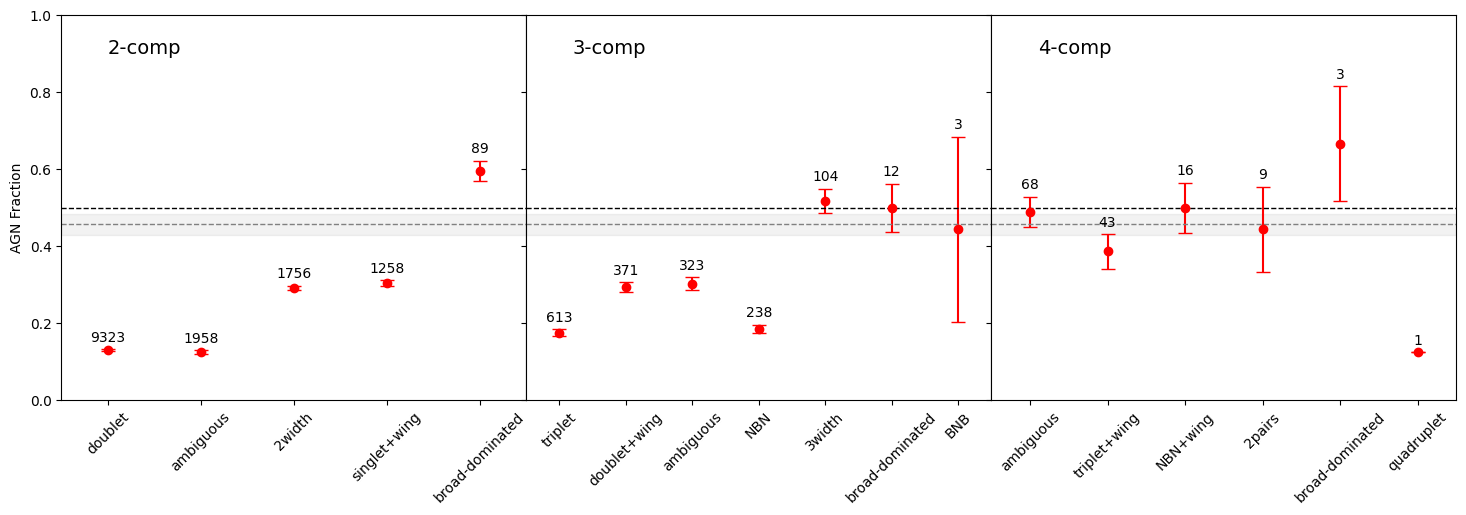

In [20]:
from scipy.stats import bootstrap
fig, ax = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
plt.subplots_adjust(wspace=0.0)
for i in range(2, 5):
    for j, cl in enumerate(classification[classification['N_KIN'] == i]['KIN_CLASS'].value_counts(normalize=False).index):
        # print(f'Class {j}: {cl}, Count: {classification[classification['N_KIN'] == i]['KIN_CLASS'].value_counts(normalize=False)[cl]}')
        sub = classification[(classification['N_KIN'] == i) & (classification['KIN_CLASS'] == cl)]
        if len(sub) > 1:
            err = bootstrap((sub['AGN_FRAC'].values,), np.mean, confidence_level=0.95, n_resamples=10000)
            ax[i-2].errorbar(x=j, y=sub['AGN_FRAC'].mean(), yerr=err.standard_error, fmt='o', capsize=5, color='r')
            ax[i-2].text(j, sub['AGN_FRAC'].mean() + err.standard_error + 0.02, f'{len(sub)}', ha='center', fontsize=10)
        else:
            ax[i-2].errorbar(x=j, y=sub['AGN_FRAC'].mean(), yerr=0, fmt='o', capsize=5, color='r')
            ax[i-2].text(j, sub['AGN_FRAC'].mean() + 0.02, f'{len(sub)}', ha='center', fontsize=10)
        ax[i-2].set_xticks(range(len(classification[classification['N_KIN'] == i]['KIN_CLASS'].value_counts())))
        ax[i-2].set_xticklabels(classification[classification['N_KIN'] == i]['KIN_CLASS'].value_counts().index, rotation=45)

    ax[i-2].text(0.1, 0.9, f'{i}-comp', transform=ax[i-2].transAxes, fontsize=14, ha='left')
    ax[i-2].set_ylim(0, 1)
    ax[i-2].set_xlim(-0.5, len(classification[classification['N_KIN'] == i]['KIN_CLASS'].value_counts()) - 0.5)
    ax[i-2].axhline(y=0.5, color='k', linestyle='--', linewidth=1)
sub = classification[classification['N_KIN'] == i]
err = bootstrap((sub['AGN_FRAC'].values,), np.mean, confidence_level=0.95, n_resamples=10000)
for i in range(2, 5):
    ax[i-2].axhline(y=sub['AGN_FRAC'].mean(), color='gray', linestyle='--', linewidth=1)
    ax[i-2].fill_between(x=[ax[i-2].get_xlim()[0], ax[i-2].get_xlim()[1]], y1=sub['AGN_FRAC'].mean()-err.standard_error, y2=sub['AGN_FRAC'].mean()+err.standard_error, color='gray', alpha=0.1)
ax[0].set_ylabel('AGN Fraction')

In [71]:
crit = (classification['N_KIN']==3) & (classification['KIN_CLASS']=='triplet') & (classification['AMP_LINE'] == 'Halpha')
print(classification[crit]['AGN_FRAC'].describe())
classification[crit].sort_values(by='AGN_FRAC', ascending=False).head(50)

count    597.000000
mean       0.162479
std        0.207141
min        0.000000
25%        0.000000
50%        0.166667
75%        0.166667
max        1.000000
Name: AGN_FRAC, dtype: float64


,TARGETID,KIN_CLASS,N_KIN,N_WING,WING_KIND,WING_DV,WING_IDX,WING_SIGMA,SYM,BROAD_DOM,...,CNT_N,CNT_M,CNT_B,AMP_LINE,CNT_SF,CNT_COMP,CNT_AGN,CNT_LINER,LOGSFR,AGN_FRAC
29930,39627782220681168,triplet,3,0,None,NaN,-1,NaN,SYM,False,...,3,0,0,Halpha,0,0,3,0,NaN,1.000000
28841,39627781998382018,triplet,3,0,None,NaN,-1,NaN,SYM,False,...,3,0,0,Halpha,0,1,2,0,0.584078,0.833333
13967,39627758241845066,triplet,3,0,None,NaN,-1,NaN,SYM,False,...,3,0,0,Halpha,0,1,2,0,-1.207420,0.833333
5884,39627746170637994,triplet,3,0,None,NaN,-1,NaN,SYM,False,...,3,0,0,Halpha,0,1,2,0,-1.855190,0.833333
6614,39627751551926536,triplet,3,0,None,NaN,-1,NaN,SYM,False,...,3,0,0,Halpha,0,1,2,0,0.181683,0.833333
7218,39627751673565356,triplet,3,0,None,NaN,-1,NaN,SYM,False,...,3,0,0,Halpha,0,1,2,0,-0.245758,0.833333
45344,39627806262429928,triplet,3,0,None,NaN,-1,NaN,SYM,False,...,3,0,0,Halpha,0,1,2,0,0.516050,0.833333
7777,39627751799390492,triplet,3,0,None,NaN,-1,NaN,ASYM,False,...,3,0,0,Halpha,0,1,2,0,0.452389,0.833333
9207,39627752072024332,triplet,3,0,None,NaN,-1,NaN,SYM,False,...,3,0,0,Halpha,0,1,2,0,0.413387,0.833333
11048,39627757671419638,triplet,3,0,None,NaN,-1,NaN,SYM,False,...,3,0,0,Halpha,0,1,1,1,0.059679,0.833333


In [72]:
# plt.hist(classification[crit]['WING_DV'].dropna(), bins=50, range=(-500, 500))
# plt.axvline(0, color='k', linestyle='--')
# plt.show()

In [73]:
classification[classification['TARGETID']==39627812436446420]

,TARGETID,KIN_CLASS,N_KIN,N_WING,WING_KIND,WING_DV,WING_IDX,WING_SIGMA,SYM,BROAD_DOM,...,CNT_N,CNT_M,CNT_B,AMP_LINE,CNT_SF,CNT_COMP,CNT_AGN,CNT_LINER,LOGSFR,AGN_FRAC
50076,39627812436446420,singlet+wing,2,1,ABSOLUTE,-600.0,0,657.766113,None,False,...,0,1,1,NII6583,1,0,0,1,1.220821,0.5


In [74]:
# dp_components[(dp_components['TARGETID']==39627739405223617)&(dp_components['LINE']=='Halpha')]

In [75]:
# crit = (classification['KIN_CLASS']=='2-pairs') & (classification['N_KIN']==4)
# dp_components[dp_components['TARGETID'].isin(classification[crit]['TARGETID'])].head(10)

In [76]:
# crit_1 = (classification['KIN_CLASS']=='singlet+wing') & (classification['N_KIN']==2) & (classification['LOGSFR']>-15)
# crit_2 = (classification['KIN_CLASS']=='doublet+wing') & (classification['N_KIN']==3) & (classification['LOGSFR']>-15)
# crit_3 = (classification['KIN_CLASS']=='triplet+wing') & (classification['N_KIN']==4) & (classification['LOGSFR']>-15)
# crits = [crit_1, crit_2, crit_3]
# labels = ['singlet+wing', 'doublet+wing', 'triplet+wing']


In [77]:
crit_1 = ((classification['KIN_CLASS']=='singlet+wing')|(classification['KIN_CLASS']=='2width')) & (classification['N_KIN']==2) & (classification['LOGSFR']>-15)
crit_2 = (classification['KIN_CLASS']=='doublet+wing') & (classification['N_KIN']==3) & (classification['LOGSFR']>-15)
crits = [crit_1, crit_2]
labels = ['singlet+wing', 'doublet+wing']


In [78]:
# crit_1 = (classification['N_KIN']==1) & (classification['LOGSFR']>-15)
# crit_2 = (classification['KIN_CLASS']=='ambiguous') & (classification['N_KIN']==2) & (classification['LOGSFR']>-15)
# crit_3 = (classification['KIN_CLASS']=='doublet') & (classification['N_KIN']==2) & (classification['LOGSFR']>-15)
# crit_4 = (classification['KIN_CLASS']=='triplet') & (classification['N_KIN']==3) & (classification['LOGSFR']>-15)
# crits = [crit_1, crit_2, crit_3, crit_4]
# labels = ['singlet', 'doublet(amb)', 'doublet', 'triplet']

In [79]:
# print(len(classification[crit_1]), len(classification[crit_2]), len(classification[crit_3]), len(classification[crit_4]))

In [80]:
# crit_1 = (classification['N_KIN']==1) & (classification['LOGSFR']>-15)
# crit_2 = ((classification['KIN_CLASS']=='singlet+wing')|(classification['KIN_CLASS']=='2width')) & (classification['N_KIN']==2) & (classification['LOGSFR']>-15)
# crits = [crit_1, crit_2]
# labels = ['singlet', 'singlet+wing']

In [81]:
# crit_1 = ((classification['KIN_CLASS']=='doublet')) & (classification['N_KIN']==2) & (classification['LOGSFR']>-15)
# crit_2 = (classification['KIN_CLASS']=='doublet+wing') & (classification['N_KIN']==3) & (classification['LOGSFR']>-15)
# crits = [crit_1, crit_2]
# labels = ['doublet', 'doublet+wing']

In [82]:
# crit_1 = (classification['KIN_CLASS']=='triplet') & (classification['N_KIN']==3) 
# crit_2 = (classification['KIN_CLASS']=='triplet+wing') & (classification['N_KIN']==4) 
# crits = [crit_1, crit_2]
# labels = ['triplet', 'triplet+wing']

In [83]:
z_ranges = [(0, 0.1), (0.1, 0.2), (0.2, 0.3), (0.3, 0.45)]

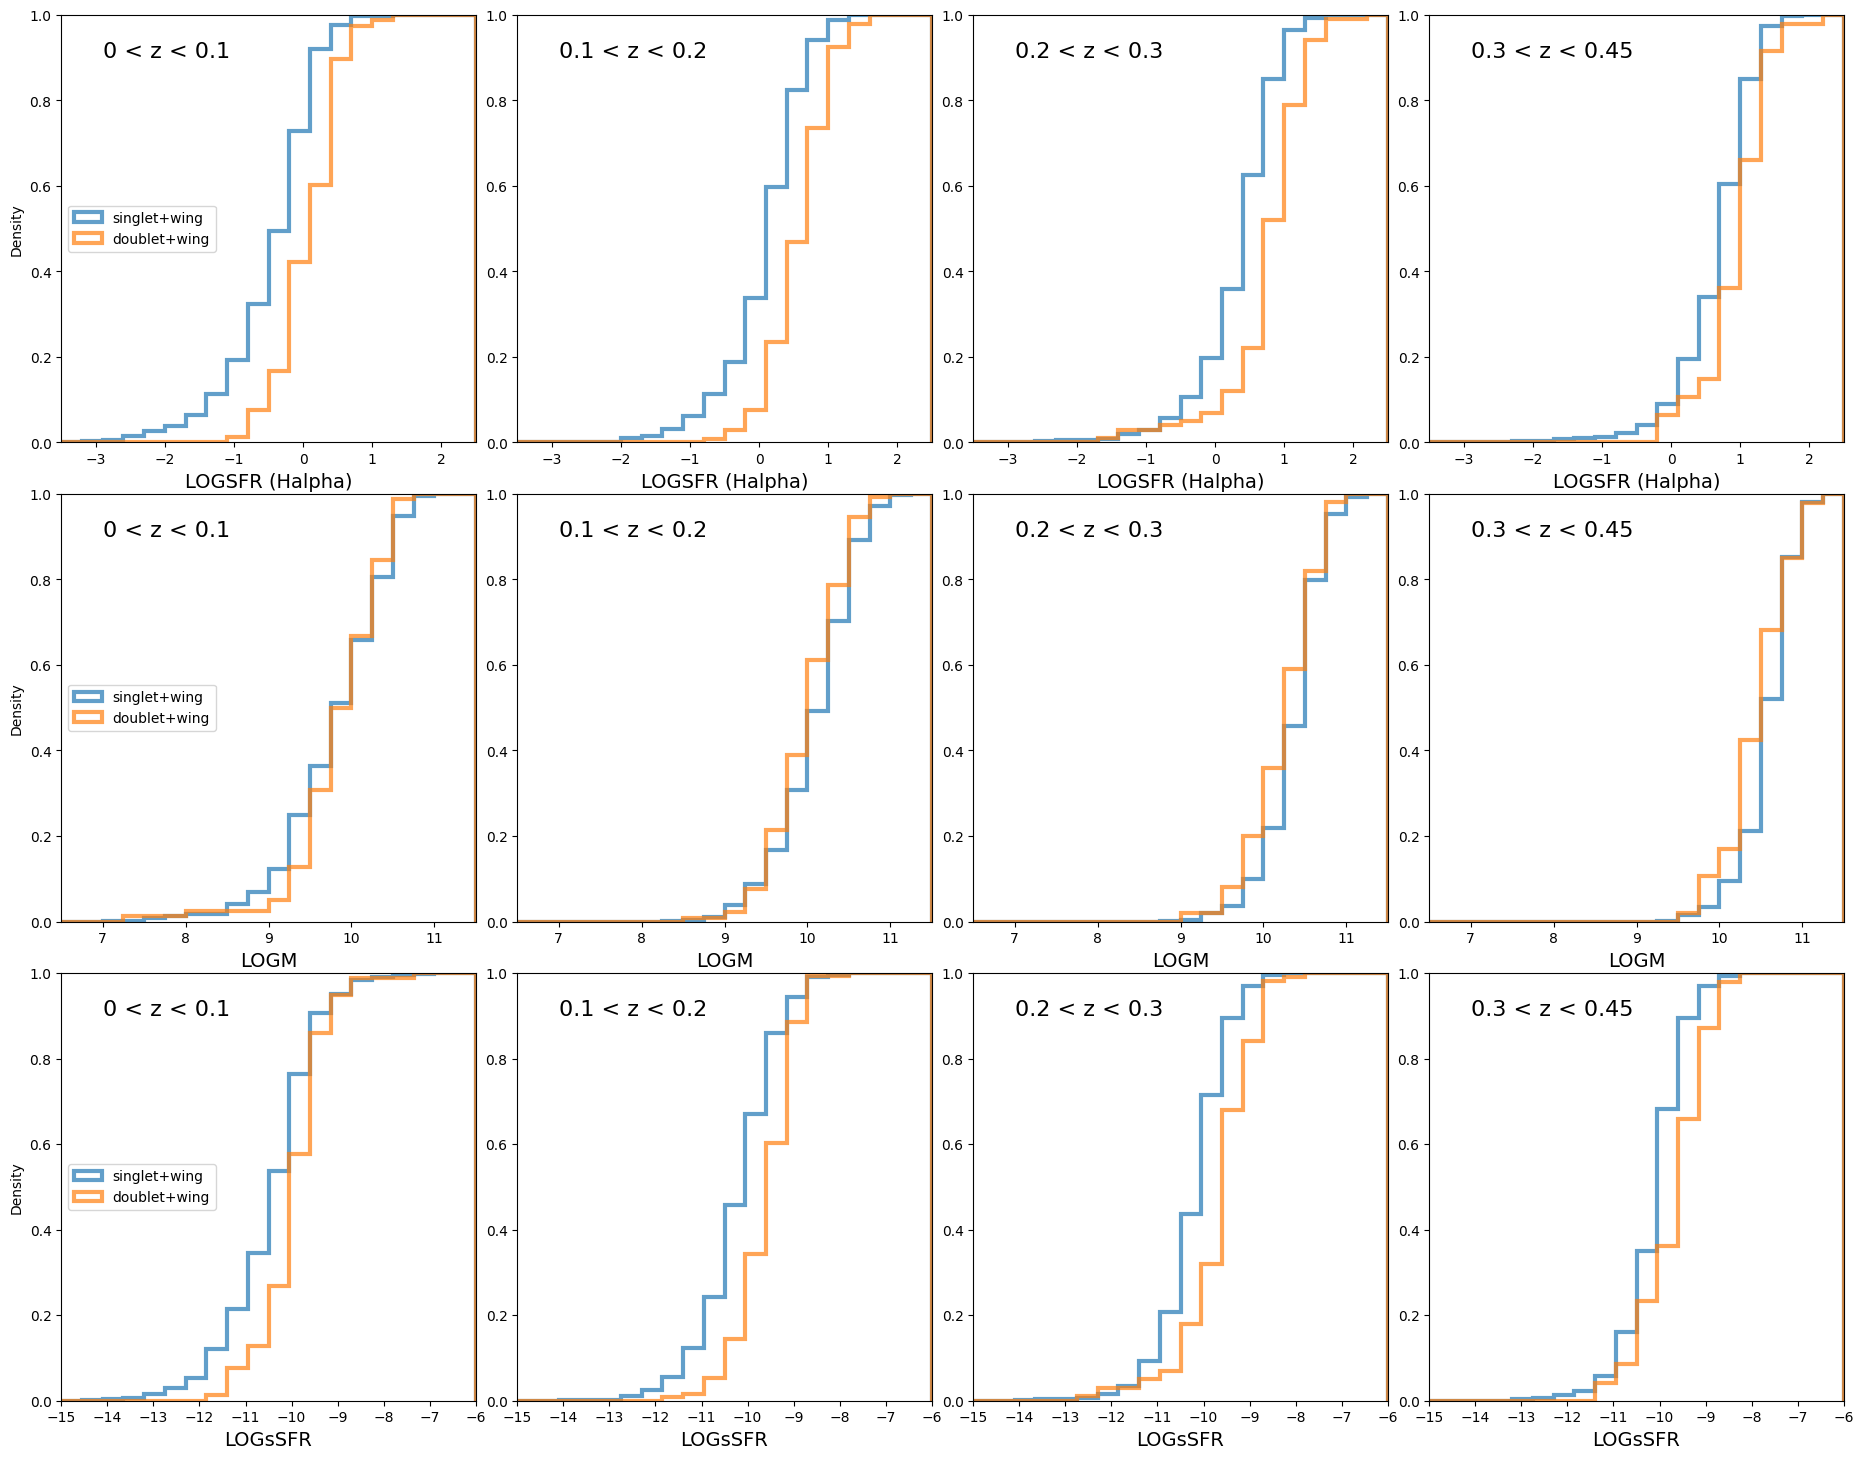

In [84]:
fig, axes = plt.subplots(3, 4, figsize=(23, 18), sharex='row', sharey=False)
plt.subplots_adjust(hspace=0.12, wspace=0.1)


ax = axes[0, :]
# colors = plt.cm.cool(np.linspace(0.3, 1, len(crits)))
for i, z_range in enumerate(z_ranges):
    for j, crit in enumerate(crits):
        sub = dp_parent[dp_parent['TARGETID'].isin(classification[crit]['TARGETID'])]
        sub = sub[(sub['Z'] >= z_range[0]) & (sub['Z'] < z_range[1])]
        sub = classification[classification['TARGETID'].isin(sub['TARGETID'])]
        ax[i].hist(sub['LOGSFR'], range=(-3.5, 2.5), bins=20, alpha=0.7, label=labels[j], density=True, histtype='step', linewidth=3, cumulative=True)
    # axes[i].set_title(f"{z_range[0]} < z < {z_range[1]}")
    ax[i].text(0.1, 0.9, f"{z_range[0]} < z < {z_range[1]}", transform=ax[i].transAxes, ha="left", fontsize=16)
    ax[i].set_ylim(0, 1)
    ax[i].set_xlim(-3.5, 2.5)
    ax[i].set_xlabel("LOGSFR (Halpha)", fontsize=14)
ax[0].legend(fontsize=10, loc='center left')
ax[0].set_ylabel("Density")

ax = axes[1, :]
for i, z_range in enumerate(z_ranges):
    for j, crit in enumerate(crits):
        sub = dp_parent[dp_parent['TARGETID'].isin(classification[crit]['TARGETID'])]
        sub = sub[(sub['Z'] >= z_range[0]) & (sub['Z'] < z_range[1])]
        ax[i].hist(sub['LOGM'], range=(6.5, 11.5), bins=20, alpha=0.7, label=labels[j], density=True, histtype='step', linewidth=3, cumulative=True)
    # axes[i].set_title(f"{z_range[0]} < z < {z_range[1]}")
    ax[i].text(0.1, 0.9, f"{z_range[0]} < z < {z_range[1]}", transform=ax[i].transAxes, ha="left", fontsize=16)
    ax[i].set_ylim(0, 1)
    ax[i].set_xlim(6.5, 11.5)
    ax[i].set_xlabel("LOGM", fontsize=14)
ax[0].legend(fontsize=10, loc='center left')
ax[0].set_ylabel("Density")

ax = axes[2, :]
for i, z_range in enumerate(z_ranges):
    for j, crit in enumerate(crits):
        sub = dp_parent[dp_parent['TARGETID'].isin(classification[crit]['TARGETID'])]
        sub = sub[(sub['Z'] >= z_range[0]) & (sub['Z'] < z_range[1])]
        sub_sfr = classification[classification['TARGETID'].isin(sub['TARGETID'])]
        ax[i].hist(sub_sfr['LOGSFR']-sub['LOGM'], range=(-15, -6), bins=20, alpha=0.7, label=labels[j], density=True, histtype='step', linewidth=3, cumulative=True)
    # axes[i].set_title(f"{z_range[0]} < z < {z_range[1]}")
    ax[i].text(0.1, 0.9, f"{z_range[0]} < z < {z_range[1]}", transform=ax[i].transAxes, ha="left", fontsize=16)
    ax[i].set_ylim(0, 1)
    ax[i].set_xlim(-15, -6)
    ax[i].set_xlabel("LOGsSFR", fontsize=14)
ax[0].legend(fontsize=10, loc='center left')
ax[0].set_ylabel("Density")



plt.show()

/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_65145/1695129178.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.scatter(dp_parent[dp_components['TARGETID'].isin(classification[crit_1]['TARGETID'])]['LOGM'],
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_65145/1695129178.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dp_parent[dp_components['TARGETID'].isin(classification[crit_1]['TARGETID'])]['LOGSFR'],
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_65145/1695129178.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.scatter(dp_parent[dp_components['TARGETID'].isin(classification[crit_2]['TARGETID'])]['LOGM'],
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_65145/1695129178.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dp_parent[dp_components['TARGETID'].isin(classification[crit_2]['TARGETID

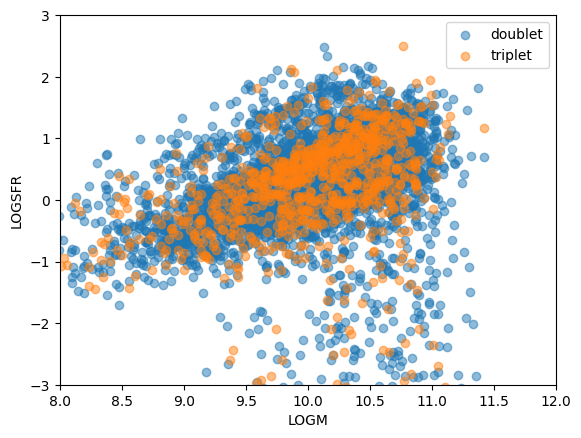

In [85]:
plt.scatter(dp_parent[dp_components['TARGETID'].isin(classification[crit_1]['TARGETID'])]['LOGM'],
             dp_parent[dp_components['TARGETID'].isin(classification[crit_1]['TARGETID'])]['LOGSFR'],
             label='doublet', alpha=0.5)
plt.scatter(dp_parent[dp_components['TARGETID'].isin(classification[crit_2]['TARGETID'])]['LOGM'],
             dp_parent[dp_components['TARGETID'].isin(classification[crit_2]['TARGETID'])]['LOGSFR'],
             label='triplet', alpha=0.5)
plt.xlabel('LOGM')
plt.ylabel('LOGSFR')
plt.xlim(8, 12)
plt.ylim(-3, 3)
plt.legend()
plt.show()


/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_65145/665025832.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.scatter(dp_parent[dp_components['TARGETID'].isin(classification[crit_1]['TARGETID'])]['LOGM'],
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_65145/665025832.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dp_parent[dp_components['TARGETID'].isin(classification[crit_1]['TARGETID'])]['Z'],
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_65145/665025832.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plt.scatter(dp_parent[dp_components['TARGETID'].isin(classification[crit_2]['TARGETID'])]['LOGM'],
/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_65145/665025832.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dp_parent[dp_components['TARGETID'].isin(classification[crit_2]['TARGETID'])]['Z']

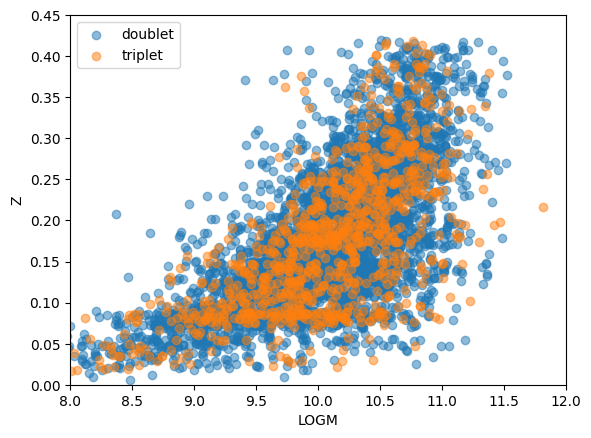

In [86]:
plt.scatter(dp_parent[dp_components['TARGETID'].isin(classification[crit_1]['TARGETID'])]['LOGM'],
             dp_parent[dp_components['TARGETID'].isin(classification[crit_1]['TARGETID'])]['Z'],
             label='doublet', alpha=0.5)
plt.scatter(dp_parent[dp_components['TARGETID'].isin(classification[crit_2]['TARGETID'])]['LOGM'],
             dp_parent[dp_components['TARGETID'].isin(classification[crit_2]['TARGETID'])]['Z'],
             label='triplet', alpha=0.5)
plt.xlabel('LOGM')
plt.ylabel('Z')
plt.xlim(8, 12)
plt.ylim(0, .45)
plt.legend()
plt.show()


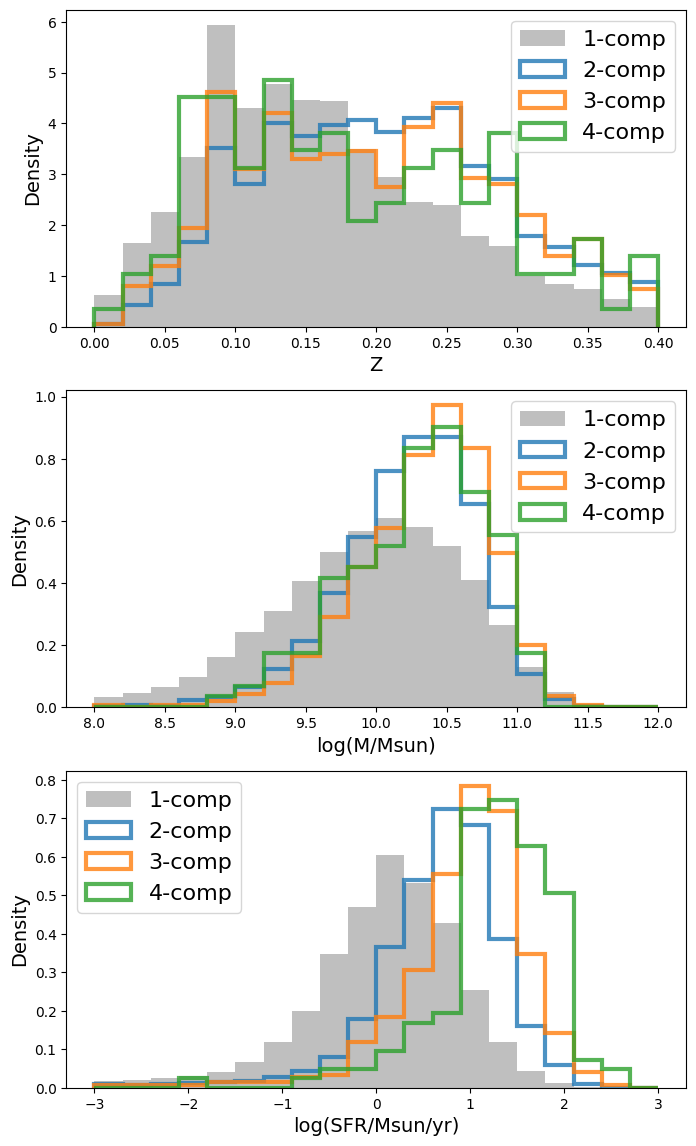

In [87]:
fig, axes = plt.subplots(3, 1, figsize=(8,14))
plt.subplots_adjust(wspace=0.1)    
for i, ax in enumerate(axes):
    for j in range(4):
        if j == 0:
            ax.hist(dp_parent[dp_parent['N_COMP_FIT'] == j+1][['Z', 'LOGM', 'LOGSFR'][i]], alpha=0.5, label=f'{j+1}-comp', density=True, range=[(0, 0.4), (8, 12), (-3, 3)][i], bins=20, linewidth=3, color='gray')
        else:
            ax.hist(dp_sample[dp_sample['N_COMP_FIT'] == j+1][['Z', 'LOGM', 'LOGSFR'][i]], alpha=0.8, label=f'{j+1}-comp', density=True, range=[(0, 0.4), (8, 12), (-3, 3)][i], bins=20, histtype='step', linewidth=3)
    ax.legend(fontsize=16)
    ax.set_xlabel(['Z', 'log(M/Msun)', 'log(SFR/Msun/yr)'][i], fontsize=14)
    ax.set_ylabel('Density', fontsize=14)
plt.show()

In [88]:
crit = (classification['N_KIN']==2) & (classification['WING_SIGMA']>0) & (classification['CNT_AGN']==0)
sub = classification[crit]
sub.head()

,TARGETID,KIN_CLASS,N_KIN,N_WING,WING_KIND,WING_DV,WING_IDX,WING_SIGMA,SYM,BROAD_DOM,...,CNT_N,CNT_M,CNT_B,AMP_LINE,CNT_SF,CNT_COMP,CNT_AGN,CNT_LINER,LOGSFR,AGN_FRAC
7,39627739380057763,singlet+wing,2,1,RELATIVE,-78.327950,0,141.148636,None,False,...,1,1,0,Halpha,1,1,0,0,1.149707,0.25
158,39627739434583871,singlet+wing,2,1,RELATIVE,-61.715130,0,138.158371,None,False,...,1,1,0,Halpha,1,1,0,0,0.430159,0.25
243,39627739468138955,singlet+wing,2,1,RELATIVE,75.063927,1,131.729874,None,False,...,1,1,0,Halpha,1,0,0,1,-1.120605,0.50
265,39627739476529054,singlet+wing,2,1,RELATIVE,139.719055,1,163.394348,None,False,...,1,1,0,Halpha,0,1,0,1,0.750420,0.75
266,39627739476529363,singlet+wing,2,1,RELATIVE,-8.563439,0,136.084549,None,False,...,1,1,0,Halpha,2,0,0,0,-0.508171,0.00


In [89]:
dp_parent[dp_parent['TARGETID'].isin(sub['TARGETID'])].head()

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,N_COMP,N_COMP_FIT,BIC_1,CHISQ_1,...,OII3726_FLUX_TOT,OII3729_FLUX_TOT,Hbeta_FLUX_TOT,OIII4959_FLUX_TOT,OIII5007_FLUX_TOT,NII6548_FLUX_TOT,NII6583_FLUX_TOT,Halpha_FLUX_TOT,SII6716_FLUX_TOT,SII6731_FLUX_TOT
7,39627739380057763,177.068542,-1.882260,0.242461,10.436480,-0.020428,2,2,1048.371948,987.857422,...,10.882325,14.484303,14.373573,1.456799,4.412641,21.363346,65.510559,112.543510,18.831467,12.215933
158,39627739434583871,180.336105,-1.954265,0.266465,10.621392,0.250449,2,2,1105.115601,1044.334717,...,7.553361,10.053473,13.989170,2.027095,6.140066,5.472093,16.780138,36.187923,10.382497,5.809248
243,39627739468138955,182.351227,-1.877822,0.099850,10.309482,-6.389420,2,2,1489.787109,1430.290771,...,23.083715,30.724274,16.606300,8.593532,26.029781,14.306299,43.870171,84.513428,44.698029,35.396984
265,39627739476529054,182.924194,-1.958273,0.316126,11.058071,-0.059480,2,2,1014.298035,953.197266,...,0.570423,0.759230,2.042008,0.456510,1.382767,11.212057,34.381699,46.904850,8.766283,5.968701
266,39627739476529363,182.938995,-1.994152,0.165520,9.975123,0.706706,2,2,924.623047,864.609009,...,3.204651,4.265369,9.036449,1.591900,4.821861,3.603414,11.049845,28.843342,6.621948,3.527063


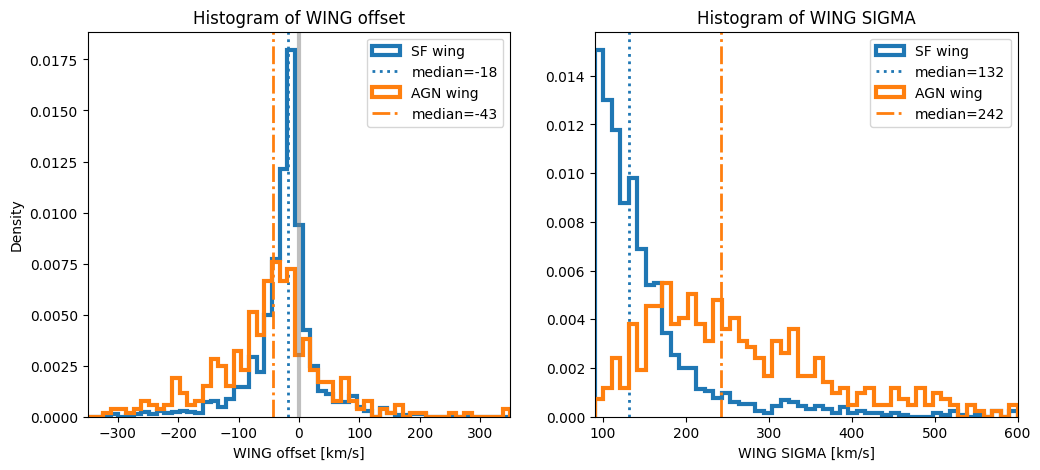

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

crit = ((classification['N_KIN']==2)|(classification['N_KIN']==3)) & (classification['WING_SIGMA']>0) & ((classification['CNT_AGN']==0)&(classification['CNT_LINER']==0))
sub = classification[crit]
axes[0].hist(sub['WING_DV'].dropna(), bins=55, range=(-350, 350), density=True, histtype='step', linewidth=3, label='SF wing')
axes[0].axvline(sub['WING_DV'].median(), color='C0', linestyle=':', label=f'median={sub["WING_DV"].median():.0f}', lw=2)

axes[1].hist(sub['WING_SIGMA'].dropna(), bins=50, range=(90, 600), density=True, histtype='step', linewidth=3, label='SF wing')
axes[1].axvline(sub['WING_SIGMA'].median(), color='C0', linestyle=':', label=f'median={sub["WING_SIGMA"].median():.0f}', lw=2)


crit = ((classification['N_KIN']==2)|(classification['N_KIN']==3)) & (classification['WING_SIGMA']>0) & (classification['CNT_SF']==0)
sub = classification[crit]
axes[0].hist(sub['WING_DV'].dropna(), bins=55, range=(-350, 350), density=True, histtype='step', linewidth=3, label='AGN wing')
axes[0].axvline(sub['WING_DV'].median(), color='C1', linestyle='-.', label=f'median={sub["WING_DV"].median():.0f}', lw=2)

axes[1].hist(sub['WING_SIGMA'].dropna(), bins=50, range=(90, 600), density=True, histtype='step', linewidth=3, label='AGN wing')
axes[1].axvline(sub['WING_SIGMA'].median(), color='C1', linestyle='-.', label=f'median={sub["WING_SIGMA"].median():.0f}', lw=2)

axes[0].axvline(0, color='gray', lw=3, alpha=0.5)
axes[0].set_xlim(-350, 350)
axes[0].set_xlabel('WING offset [km/s]')
axes[0].set_ylabel('Density')
axes[0].set_title('Histogram of WING offset')
axes[0].legend()

axes[1].set_xlim(90, 600)
axes[1].set_xlabel('WING SIGMA [km/s]')
axes[1].set_title('Histogram of WING SIGMA')
axes[1].legend()


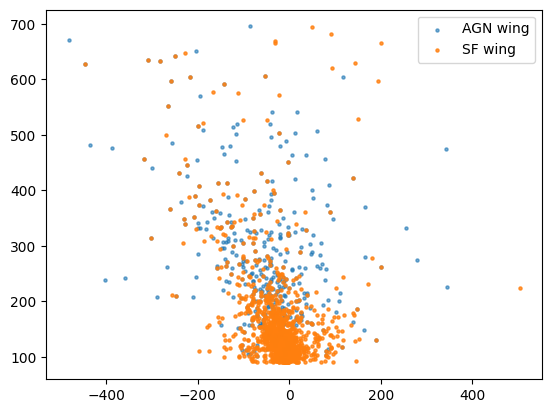

In [91]:
crit = ((classification['N_KIN']==2)|(classification['N_KIN']==3)) & (classification['WING_SIGMA']>0) & (classification['CNT_SF']==0)
sub = classification[crit]
plt.scatter(sub['WING_DV'], sub['WING_SIGMA'], alpha=0.6, s=5, label='AGN wing')

crit = ((classification['N_KIN']==2)|(classification['N_KIN']==3)) & (classification['WING_SIGMA']>0) & ((classification['CNT_AGN']==0)&(classification['CNT_LINER']==0))
sub = classification[crit]
plt.scatter(sub['WING_DV'], sub['WING_SIGMA'], alpha=0.8, s=5, label='SF wing')

plt.legend()
plt.show()

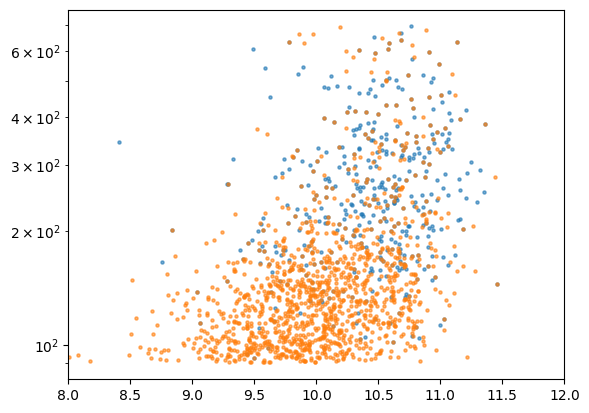

In [92]:
crit = ((classification['N_KIN']==2)|(classification['N_KIN']==3)) & (classification['WING_SIGMA']>0) & (classification['CNT_SF']==0)
sub = classification[crit]
sub_logm = dp_parent[dp_parent['TARGETID'].isin(sub['TARGETID'])]
plt.scatter(sub_logm['LOGM'], sub['WING_SIGMA'], alpha=0.6, s=5, label='AGN wing')



crit = ((classification['N_KIN']==2)|(classification['N_KIN']==3)) & (classification['WING_SIGMA']>0) & ((classification['CNT_AGN']==0)&(classification['CNT_LINER']==0))
sub = classification[crit]
sub_logm = dp_parent[dp_parent['TARGETID'].isin(sub['TARGETID'])]
plt.scatter(sub_logm['LOGM'], sub['WING_SIGMA'], alpha=0.6, s=5, label='SF wing')

plt.yscale('log')
plt.xlim(8, 12)
plt.show()

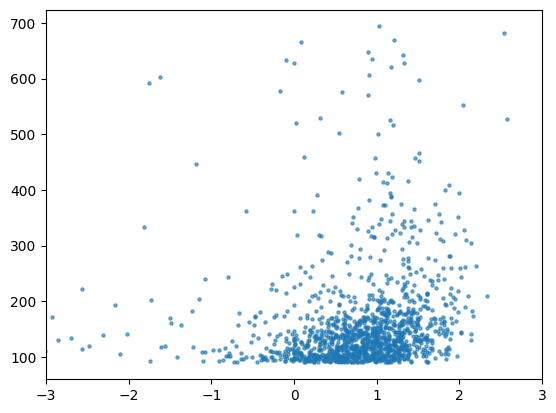

In [93]:
crit = (classification['N_KIN']!=1) & (classification['WING_SIGMA']>0) & ((classification['CNT_AGN']==0)&(classification['CNT_LINER']==0))
sub = classification[crit]
sub_logsfr = dp_parent[dp_parent['TARGETID'].isin(sub['TARGETID'])]
plt.scatter(sub_logsfr['LOGSFR'], sub['WING_SIGMA'], alpha=0.6, s=5, label='SF wing')

# plt.yscale('log')
plt.xlim(-3, 3)
plt.show()

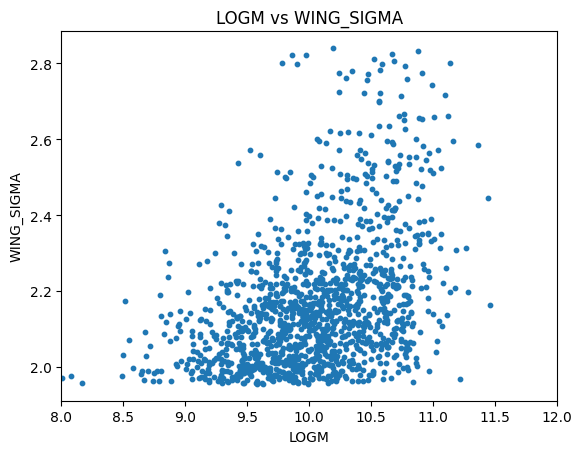

In [94]:
plt.scatter(dp_parent[dp_parent['TARGETID'].isin(sub['TARGETID'])]['LOGM'], np.log10(sub['WING_SIGMA']), s=10)
plt.xlabel('LOGM')
plt.ylabel('WING_SIGMA')
plt.title('LOGM vs WING_SIGMA')
plt.xlim(8, 12)
plt.show()

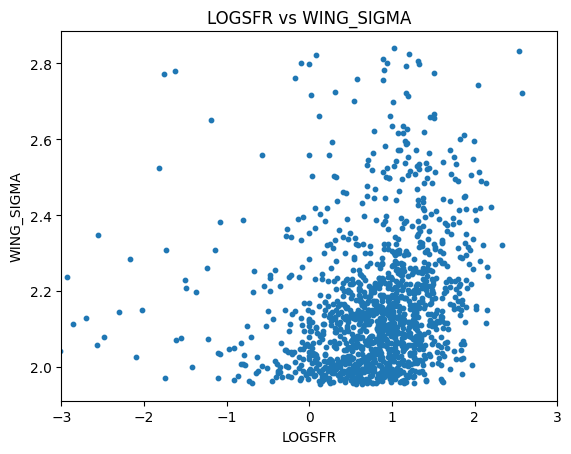

In [95]:
plt.scatter(dp_parent[dp_parent['TARGETID'].isin(sub['TARGETID'])]['LOGSFR'], np.log10(sub['WING_SIGMA']), s=10)
plt.xlabel('LOGSFR')
plt.ylabel('WING_SIGMA')
plt.title('LOGSFR vs WING_SIGMA')
plt.xlim(-3, 3)
plt.show()